# Module 2 — Class 5: Data Visualization

**Lecture:** [https://bepro-aiml.github.io/aiml-platform/#/module/2/class/5](https://bepro-aiml.github.io/aiml-platform/#/module/2/class/5)

## Rules of this notebook

1. Every chart you make is paired with a **caption sentence** in markdown — what does the chart show?
2. Every chart is paired with an **interpretation sentence** — what does it *mean* for the data?
3. A chart without a caption + interpretation gets zero points. The grade is on your reasoning, not your `plt.show()` calls.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We'll use a synthetic 'churn' dataset so everyone has the same data.
rng = np.random.default_rng(42)
n = 500
df = pd.DataFrame({
    'age': rng.integers(18, 70, n),
    'monthly_topup': rng.gamma(2, 50000, n).round(),
    'calls_per_day': rng.poisson(8, n),
    'data_gb': rng.exponential(3, n).round(2),
    'churned': rng.binomial(1, 0.25, n)
})
df.head()

,age,monthly_topup,calls_per_day,data_gb,churned
0,22,77396.0,11,8.36,0
1,58,19977.0,6,4.66,1
2,52,24794.0,10,10.76,0
3,40,267034.0,5,9.75,0
4,40,28279.0,7,0.33,0


---
## 1. Exploratory vs Explanatory

**Concept.** Two jobs for visualisation:
- *Exploratory* — for yourself. Ugly is fine, speed matters.
- *Explanatory* — for others. Beauty matters, one message per chart.

Anscombe's quartet: four datasets with identical summary statistics look completely different when plotted. **Summary stats lie; charts don't.**

### ✍️ Explain *(Quick Check 1 from the lecture)*

1. Look at `df.describe()` for `monthly_topup`. Write down the mean, median, min, max.
2. Now plot a histogram. Did the summary statistics tell you the *shape* of the distribution? Why or why not?
3. In your own words: when do you make an exploratory chart vs an explanatory one? Give one realistic example of each.

count       500.000000
mean      98540.688000
std       69196.443189
min        4638.000000
25%       48165.250000
50%       83732.500000
75%      133345.500000
max      503024.000000
Name: monthly_topup, dtype: float64


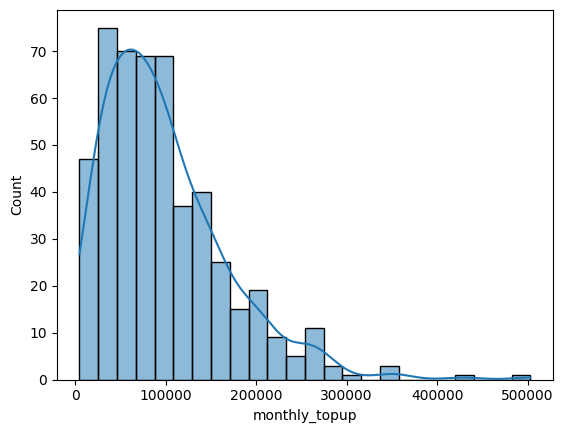

In [ ]:
# Run df.describe() and plot the histogram
print(df['monthly_topup'].describe())
sns.histplot(df, x='monthly_topup', kde=True)
plt.show()
#Use seaborn to create histogram and kde to create line distribution graph

**Caption (what the chart shows):**  
**Interpretation (what it means):**

---
## 2. Matplotlib and Seaborn

**Concept.** Reach for Seaborn first. Drop to Matplotlib when you need fine control. Every Seaborn plot is a Matplotlib figure underneath.

*Quick Check 2 from the lecture:* what does Seaborn add over Matplotlib? Answer in markdown after the practice cells.

### 🤔 Predict

Look at the four chart types below. Without running them, decide for each chart:
- What *single question* about the data does it answer?
- Which library produces it more cleanly — Matplotlib or Seaborn?

1. Histogram of one numeric column.
2. Boxplot of a numeric column split by a categorical column.
3. Scatter plot of two numeric columns coloured by a category.
4. Heatmap of a correlation matrix.

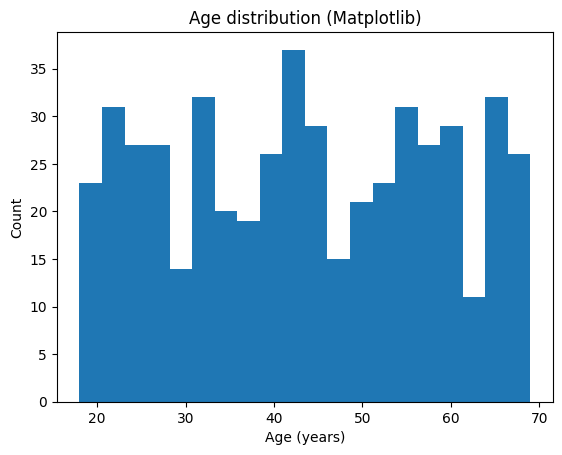

In [ ]:
# Plain Matplotlib
plt.hist(df['age'], bins=20)
plt.title('Age distribution (Matplotlib)')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()
# Create simple bar plot using mathplotlib, age from df, graph label, axis' labels

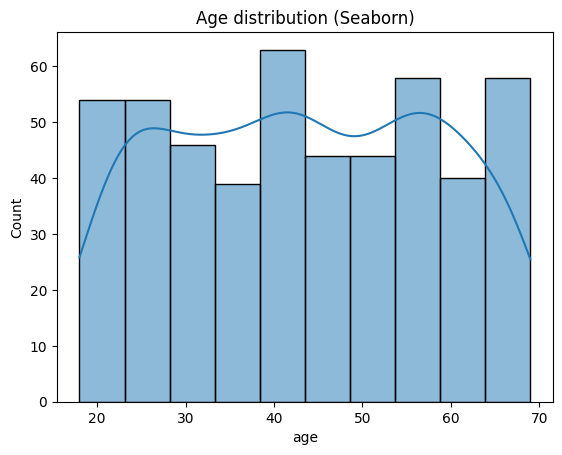

In [ ]:
# Same chart in Seaborn
sns.histplot(df, x='age', kde=True)
plt.title('Age distribution (Seaborn)')
plt.show()
# Creates bar plot using seaborn, kde is added and label

### ✍️ Explain

What did Seaborn do automatically that you would have had to write Matplotlib code for? (Hint: kde line, default styling.)

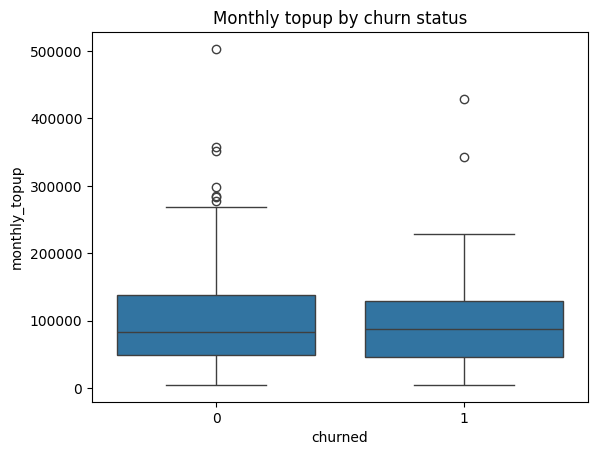

In [ ]:
# Boxplot — does monthly topup differ between churners and non-churners?
sns.boxplot(df, x='churned', y='monthly_topup')
plt.title('Monthly topup by churn status')
plt.show()
#Create boxplot using seaborn. axes are assigned to columns in df, then title for graph

**Caption:**  
**Interpretation — do churners spend more or less? Is the difference big enough to act on?**

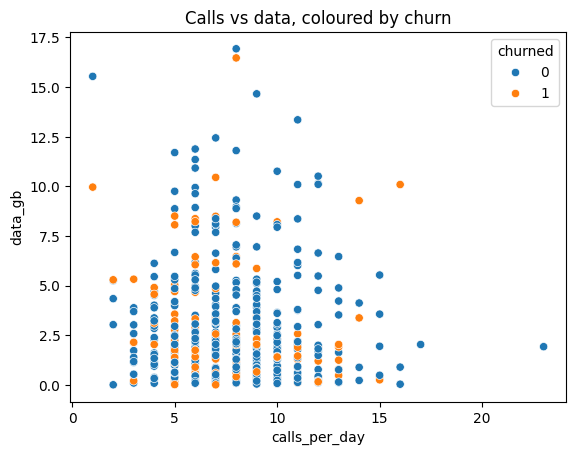

In [ ]:
sns.scatterplot(df, x='calls_per_day', y='data_gb', hue='churned')
plt.title('Calls vs data, coloured by churn')
plt.show()
#Create scattetplot using seaborn, two datas are given as input

**Caption:**  
**Interpretation — does either axis separate churners from non-churners?**

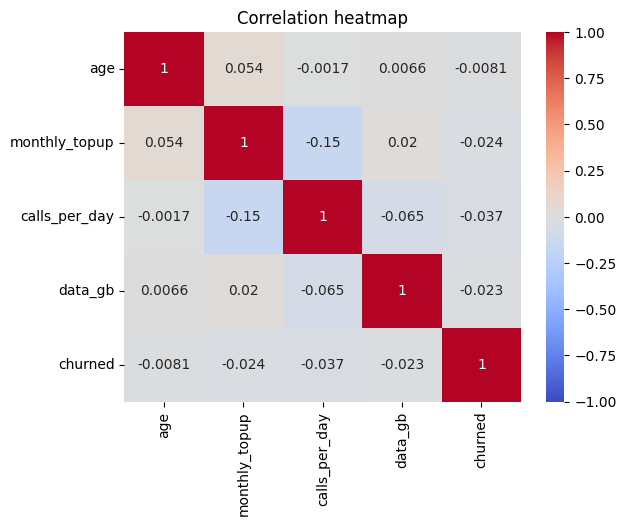

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()
#simple heatmap made using seaborn, all the numerical columns are passed in 

**Caption:**  
**Interpretation — which pair of variables has the strongest correlation? Is it positive or negative? Does it surprise you?**

### OO Matplotlib for fine control

Every Seaborn plot returns a Matplotlib axis you can customise. The OO pattern is:
```python
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y)
ax.set_xlabel('x'); ax.set_title('Squares')
fig.savefig('out.png', dpi=150)
```

### 🛠 Practice

Take ANY chart from above and remake it using the OO pattern. Add:
- A custom figure size.
- A descriptive title and labelled axes (with units).
- A caption underneath via `ax.text(...)` or a markdown cell beneath.
- Save the figure to `out.png` with `fig.savefig`.

In [9]:
# Your OO-style chart here


---
## 3. Five Rules for Honest Charts

1. **Label axes with units.** "Revenue (million soum)" not "Revenue".
2. **Bar charts start y-axis at zero.** Cutting the axis exaggerates differences.
3. **Right chart type.** Bar for categories. Line for time. Histogram for distributions. Scatter for relationships. Pie charts: almost never.
4. **Remove chartjunk.** 3D, shadows, rainbow colour bars — all must earn their place.
5. **One message per chart.** If you need a legend with 8 items, you have 8 messages. Split.

### 🛠 Audit Practice

Pick **one** chart you produced earlier in this notebook. Write a markdown audit against all 5 rules:

| Rule | yes / no / N/A | Evidence |
| --- | --- | --- |
| 1. Labels with units? | | |
| 2. Y-axis from zero (if bar)? | | |
| 3. Right chart type? | | |
| 4. No chartjunk? | | |
| 5. One clear message? | | |

Then improve the chart based on the audit and show the before/after.

### Log scale moment

*From the lecture:* plotting income linearly with a few billionaires flattens everyone else. `plt.yscale('log')` reveals the true distribution shape. Knowing when to reach for log separates junior from senior.

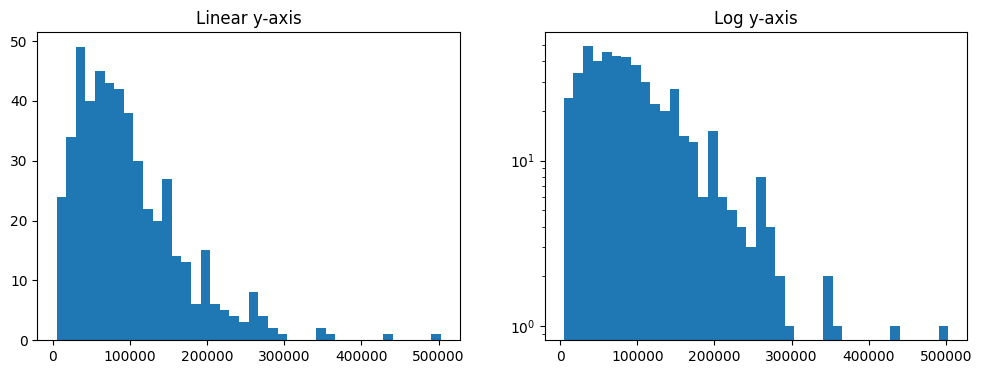

In [ ]:
# Plot monthly_topup twice — once linear, once log on the y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_topup'], bins=40)
axes[0].set_title('Linear y-axis')
axes[1].hist(df['monthly_topup'], bins=40)
axes[1].set_yscale('log')
axes[1].set_title('Log y-axis')
plt.show()
#Create two plots using seaborn. First utilizes linear scale while second uses logarithmic sclae. Basically they represent the same data

### ✍️ Explain

1. What is *visible* in the log version that was hidden in the linear version?
2. Give one realistic example from your country / industry where you would *want* a log scale, and why.

---
## End-of-class checkpoint quiz

Answer all 5 in markdown.

1. To show the distribution of one numeric column, the right chart is — bar / pie / histogram / scatter? Why?
2. What does Seaborn add over Matplotlib? Name two specific things.
3. To compare the *age distribution* between churned and non-churned customers, which chart? Why does a pie or line chart fail here?
4. Of the 5 rules for honest charts, which do you think is most often violated in real-world reporting? Give an example.
5. When would you use `plt.yscale('log')` instead of the default linear scale?